## **Analisis exploratorio**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [3]:
USUARIO = "postgres"
PASSWORD = "1028"
HOST = "localhost"
PUERTO = "5432"
BASE_DATOS = "dw_analisis_criminalidad"

engine = create_engine(
    f"postgresql+psycopg2://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}"
)

print("Conexión creada correctamente.")

Conexión creada correctamente.


#### **1. Distribución territorial**

##### **1.1. Distribucion departamental**

In [4]:
query = """
    SELECT
        u.departamento,
        d.tipo_delito,
        SUM(f.cantidad_delitos) AS cantidad_delitos
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    INNER JOIN dim_delito AS d
        ON f.id_delito = d.id_delito
    GROUP BY u.departamento, d.tipo_delito
    ORDER BY u.departamento, cantidad_delitos DESC;
"""

df_departamento_delito = pd.read_sql(query, engine)
df_departamento_delito.head()

,departamento,tipo_delito,cantidad_delitos
0,Amazonas,Lesiones personales,2567
1,Amazonas,Violencia intrafamiliar,1099
2,Amazonas,Delitos sexuales,849
3,Amazonas,Hurto a residencias y entidades comerciales,802
4,Amazonas,Amenazas,732


**Distribucion por tipo de delito**

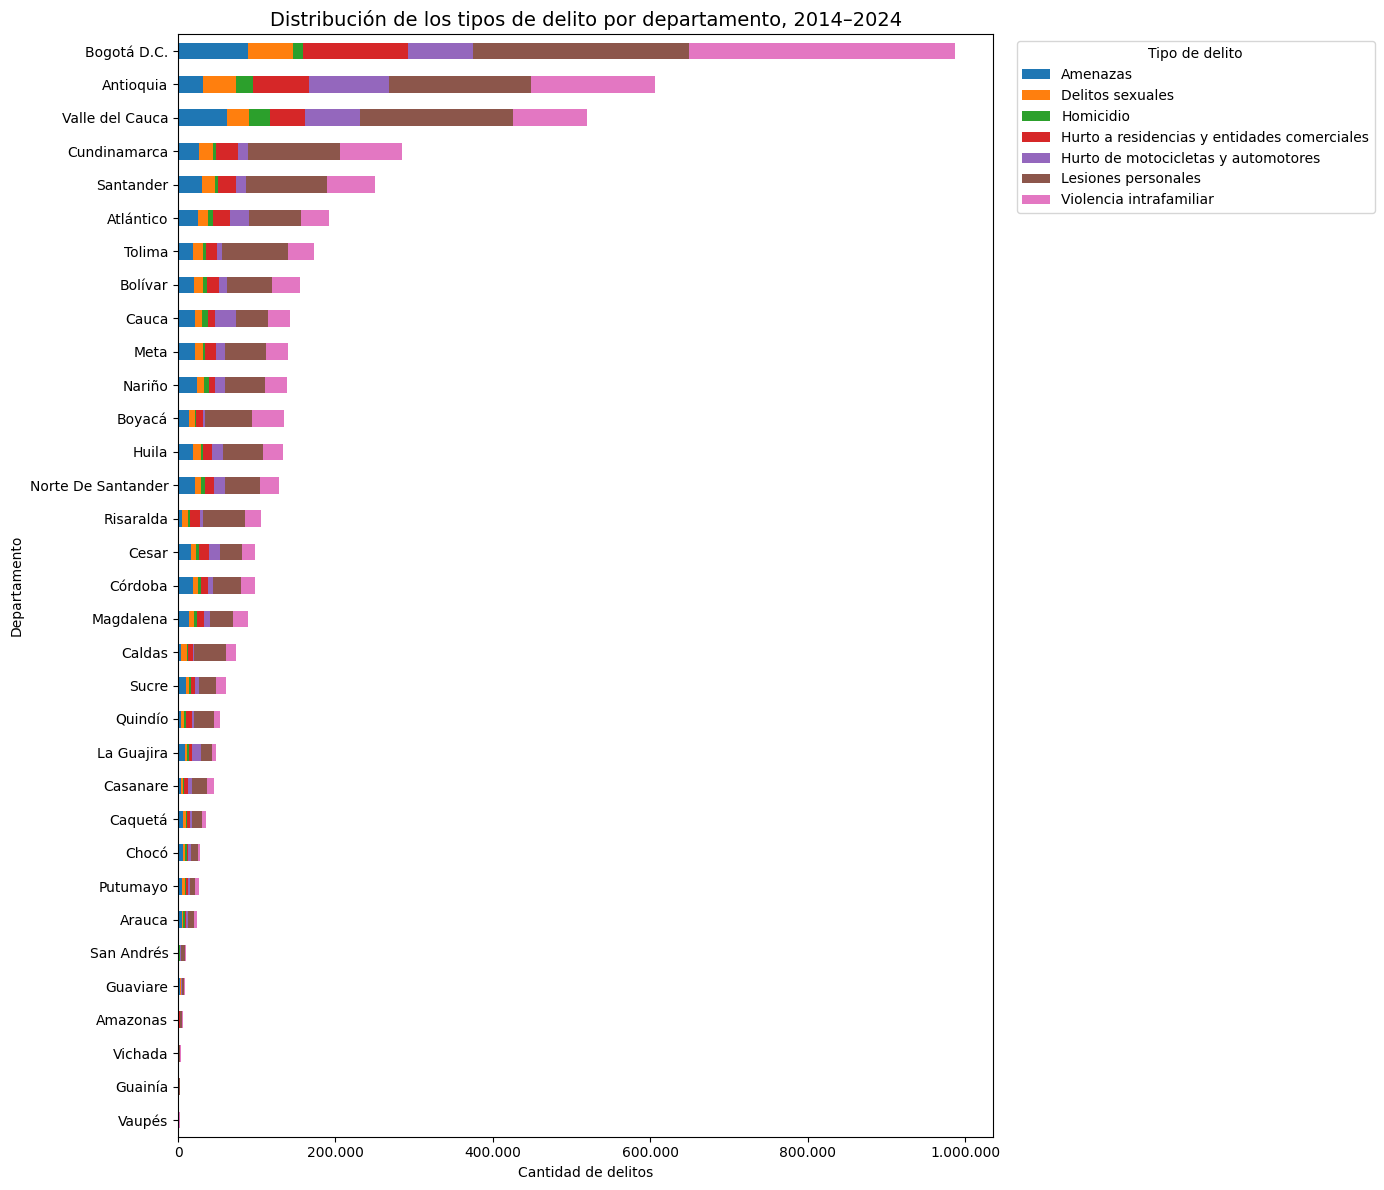

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Matriz departamento × tipo de delito
tabla_departamento_delito = (
    df_departamento_delito
    .pivot(
        index="departamento",
        columns="tipo_delito",
        values="cantidad_delitos"
    )
    .fillna(0)
)

# Ordenar departamentos de mayor a menor cantidad total
tabla_departamento_delito = tabla_departamento_delito.loc[
    tabla_departamento_delito.sum(axis=1)
    .sort_values(ascending=True)
    .index
]

# Crear figura
fig, ax = plt.subplots(figsize=(14, 12))

# Gráfico de barras apiladas
tabla_departamento_delito.plot(
    kind="barh",
    stacked=True,
    ax=ax
)

# Títulos y etiquetas
ax.set_title(
    "Distribución de los tipos de delito por departamento, 2014–2024",
    fontsize=14
)

ax.set_xlabel("Cantidad de delitos")
ax.set_ylabel("Departamento")

# Formato del eje X
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

# Leyenda
ax.legend(
    title="Tipo de delito",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [6]:
tabla_departamento_delito

tipo_delito,Amenazas,Delitos sexuales,Homicidio,Hurto a residencias y entidades comerciales,Hurto de motocicletas y automotores,Lesiones personales,Violencia intrafamiliar
departamento,,,,,,,
Vaupés,165,296,31,165,28,997,735
Guainía,365,408,28,454,44,1063,700
Vichada,517,452,182,471,226,1085,584
Amazonas,732,849,173,802,342,2567,1099
Guaviare,1994,1179,354,568,454,2820,1813
San Andrés,1003,618,289,1202,593,4891,1961
Arauca,4633,2238,1639,1919,2281,7311,4271
Putumayo,5651,2936,1910,1745,2673,6751,4561
Chocó,6084,2266,2501,2004,4039,8377,3193


**Participación de cada delito dentro de cada territorio**

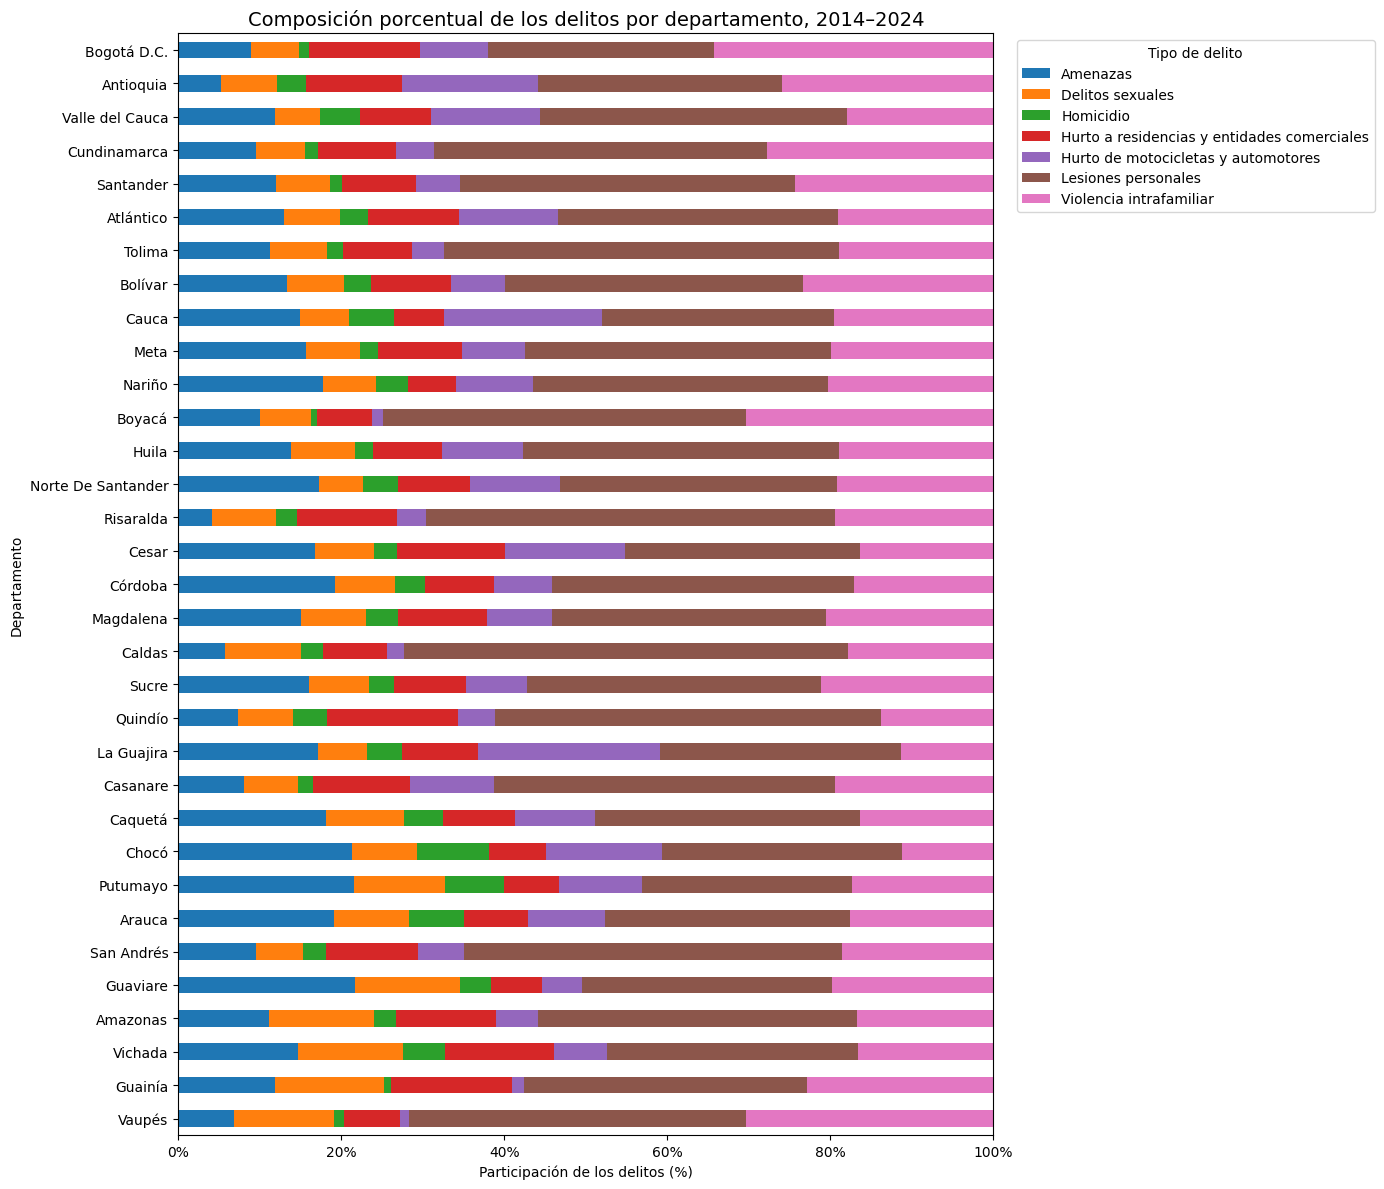

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Participación porcentual de cada delito dentro de cada departamento
tabla_porcentajes = (
    tabla_departamento_delito
    .div(
        tabla_departamento_delito.sum(axis=1),
        axis=0
    ) * 100
)

# Ordenar igual que la figura de cantidades:
# mayor volumen total arriba
orden_departamentos = (
    tabla_departamento_delito
    .sum(axis=1)
    .sort_values(ascending=True)
    .index
)

tabla_porcentajes = tabla_porcentajes.loc[orden_departamentos]

# Figura
fig, ax = plt.subplots(figsize=(14, 12))

tabla_porcentajes.plot(
    kind="barh",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Composición porcentual de los delitos por departamento, 2014–2024",
    fontsize=14
)

ax.set_xlabel("Participación de los delitos (%)")
ax.set_ylabel("Departamento")

ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlim(0, 100)

ax.legend(
    title="Tipo de delito",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [8]:
tabla_porcentajes

tipo_delito,Amenazas,Delitos sexuales,Homicidio,Hurto a residencias y entidades comerciales,Hurto de motocicletas y automotores,Lesiones personales,Violencia intrafamiliar
departamento,,,,,,,
Vaupés,6.826645,12.246587,1.282582,6.826645,1.158461,41.249483,30.409599
Guainía,11.920314,13.324624,0.914435,14.826911,1.436969,34.715872,22.860875
Vichada,14.700028,12.851862,5.174865,13.392096,6.425931,30.850156,16.605061
Amazonas,11.151737,12.934186,2.635588,12.218160,5.210238,39.107252,16.742840
Guaviare,21.716402,12.840340,3.855369,6.186016,4.944457,30.712263,19.745154
San Andrés,9.500805,5.853936,2.737520,11.385810,5.617126,46.329450,18.575353
Arauca,19.072123,9.212910,6.747077,7.899720,9.389923,30.096328,17.581920
Putumayo,21.546498,11.194570,7.282571,6.653449,10.191787,25.740649,17.390475
Chocó,21.374368,7.960933,8.786537,7.040472,14.189854,29.430157,11.217678


In [9]:
print("Total de delitos:", df_departamento_delito["cantidad_delitos"].sum())
print("Departamentos:", df_departamento_delito["departamento"].nunique())
print("Tipos de delito:", df_departamento_delito["tipo_delito"].nunique())

Total de delitos: 4805136
Departamentos: 33
Tipos de delito: 7


In [10]:
orden_departamentos = (
    tabla_departamento_delito
    .sum(axis=1)
    .sort_values(ascending=False)
    .index
)

tabla_departamento_delito_ordenada = (
    tabla_departamento_delito
    .loc[orden_departamentos]
)

tabla_departamento_delito_ordenada

tipo_delito,Amenazas,Delitos sexuales,Homicidio,Hurto a residencias y entidades comerciales,Hurto de motocicletas y automotores,Lesiones personales,Violencia intrafamiliar
departamento,,,,,,,
Bogotá D.C.,88405,57373,12652,133960,82615,273862,337608
Antioquia,32019,41389,21886,71160,100928,180781,157423
Valle del Cauca,61631,28505,26080,44674,69985,195098,93524
Cundinamarca,27146,17171,4546,27007,13463,116046,78945
Santander,30198,16506,3524,23003,13464,102781,61063
Atlántico,25021,13119,6772,21248,23417,66167,36567
Tolima,19555,12014,3477,14557,6797,83762,32860
Bolívar,20646,10850,5187,15265,10141,56682,36131
Cauca,21230,8676,7783,8822,27500,40563,27773


##### **1.2. Distribucion municipal**

In [11]:
# Consulta para obtener los 10 municipios con mayor cantidad de registros
query_top10 = """
    SELECT
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS cantidad_delitos
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.municipio,
        u.departamento
    ORDER BY
        cantidad_delitos DESC
    LIMIT 10;
"""

df_top10 = pd.read_sql(query_top10, engine)
df_top10

,municipio,departamento,cantidad_delitos
0,Bogotá D.C. (Ct),Bogotá D.C.,986475
1,Medellín (Ct),Antioquia,314391
2,Cali (Ct),Valle del Cauca,293368
3,Barranquilla (Ct),Atlántico,117470
4,Cartagena (Ct),Bolívar,97870
5,Villavicencio (Ct),Meta,86880
6,Ibagué (Ct),Tolima,86800
7,Bucaramanga (Ct),Santander,84142
8,Cúcuta (Ct),Norte De Santander,77577
9,Pasto (Ct),Nariño,75557


In [12]:
query_municipios_delito = """
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
)

SELECT
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_ubicacion AS u
    ON f.id_ubicacion = u.id_ubicacion
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN top_municipios AS tm
    ON f.id_ubicacion = tm.id_ubicacion
GROUP BY
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    tm.total_municipio
ORDER BY
    tm.total_municipio DESC,
    cantidad_delitos DESC;
"""

df_municipios_delito = pd.read_sql(query_municipios_delito, engine)

df_municipios_delito

,municipio,departamento,tipo_delito,cantidad_delitos
0,Bogotá D.C. (Ct),Bogotá D.C.,Violencia intrafamiliar,337608
1,Bogotá D.C. (Ct),Bogotá D.C.,Lesiones personales,273862
2,Bogotá D.C. (Ct),Bogotá D.C.,Hurto a residencias y entidades comerciales,133960
3,Bogotá D.C. (Ct),Bogotá D.C.,Amenazas,88405
4,Bogotá D.C. (Ct),Bogotá D.C.,Hurto de motocicletas y automotores,82615
...,...,...,...,...
65,Pasto (Ct),Nariño,Amenazas,11094
66,Pasto (Ct),Nariño,Hurto de motocicletas y automotores,6318
67,Pasto (Ct),Nariño,Hurto a residencias y entidades comerciales,4755
68,Pasto (Ct),Nariño,Delitos sexuales,4024


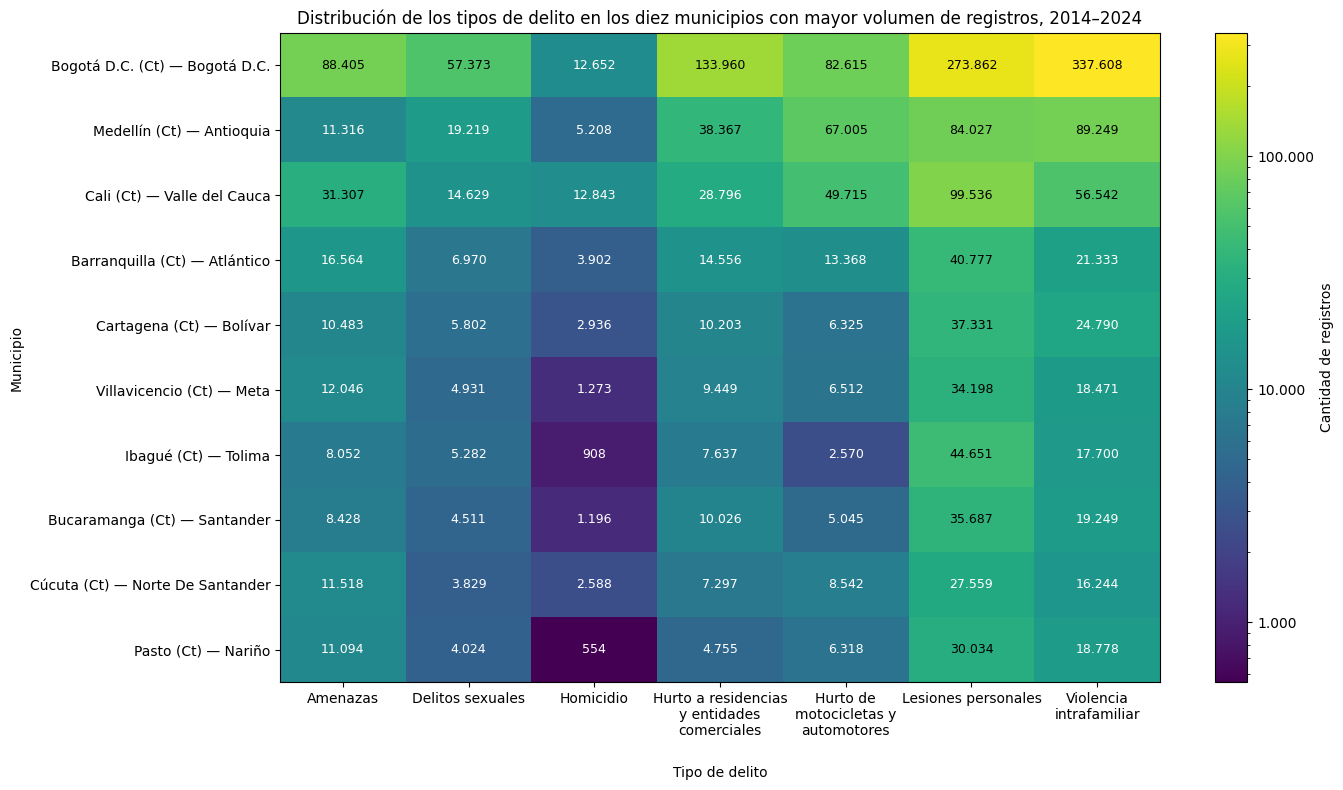

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from textwrap import fill

# ==========================================================
# PREPARACIÓN DE LOS DATOS
# ==========================================================

# Crear tabla municipio x tipo de delito
tabla_heatmap = df_municipios_delito.pivot_table(
    index=["municipio", "departamento"],
    columns="tipo_delito",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

# Calcular total para ordenar los municipios
tabla_heatmap["Total"] = tabla_heatmap.sum(axis=1)

# Ordenar de mayor a menor volumen
tabla_heatmap = tabla_heatmap.sort_values("Total", ascending=False)

# Eliminar columna auxiliar
tabla_heatmap = tabla_heatmap.drop(columns="Total")

# Limpiar nombres
municipios = [
    f"{municipio} — {departamento.replace(' (Ct)', '')}"
    for municipio, departamento in tabla_heatmap.index
]

# Convertir a matriz
datos = tabla_heatmap.to_numpy()

# ==========================================================
# ESCALA LOGARÍTMICA PARA LA INTENSIDAD DEL COLOR
# ==========================================================

# Obtener el menor valor positivo para evitar problemas con log(0)
valores_positivos = datos[datos > 0]

norm = LogNorm(
    vmin=valores_positivos.min(),
    vmax=valores_positivos.max()
)

# ==========================================================
# CREACIÓN DEL HEATMAP
# ==========================================================

# Etiquetas originales
delitos = tabla_heatmap.columns.tolist()

# Partir automáticamente las etiquetas largas en varias líneas
delitos_cortos = [
    fill(delito, width=20)
    for delito in delitos
]

fig, ax = plt.subplots(figsize=(14, 8))

imagen = ax.imshow(
    datos,
    aspect="auto",
    norm=norm
)

# Eje X: tipos de delito
ax.set_xticks(np.arange(len(delitos)))
ax.set_xticklabels(
    delitos_cortos,
    rotation=0,
    ha="center"
)

# Eje Y: municipios
ax.set_yticks(np.arange(len(municipios)))
ax.set_yticklabels(municipios)

# Etiquetas
ax.set_xlabel("Tipo de delito", labelpad=20)
ax.set_ylabel("Municipio")

ax.set_title(
    "Distribución de los tipos de delito en los diez municipios con mayor volumen de registros, 2014–2024"
)

# ==========================================================
# VALORES EN LAS CELDAS
# ==========================================================

for i in range(datos.shape[0]):
    for j in range(datos.shape[1]):
        valor = datos[i, j]

        texto = f"{int(valor):,}".replace(",", ".")

        # Determinar contraste del texto según intensidad
        if valor > 0:
            # Obtener el color de fondo de la celda
            rgba = imagen.cmap(norm(valor))

            # Calcular luminancia del color
            r, g, b, _ = rgba

            luminancia = (
                0.299 * r +
                0.587 * g +
                0.114 * b
            )

            # Fondo oscuro -> texto blanco
            # Fondo claro -> texto negro
            color_texto = "white" if luminancia < 0.5 else "black"

            ax.text(
                j,
                i,
                texto,
                ha="center",
                va="center",
                fontsize=9,
                color=color_texto
            )

# ==========================================================
# BARRA DE COLOR
# ==========================================================

cbar = fig.colorbar(imagen, ax=ax)

cbar.set_label("Cantidad de registros")

cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", "."))
)

plt.tight_layout()
plt.show()

#### **2. Caracterizacion de las victimas**

##### **2.1. Caracterizacion general de las victimas**

In [ ]:
query_genero = """
SELECT
    d.tipo_delito,
    v.genero,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
GROUP BY
    d.tipo_delito,
    v.genero
ORDER BY
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_genero = pd.read_sql(query_genero, engine)

print("Resultados: tipo de delito × género")
display(df_genero)

Resultados: tipo de delito × género


,tipo_delito,genero,cantidad_delitos
0,Amenazas,Masculino,308389
1,Amenazas,Femenino,226369
2,Amenazas,No reportado,2176
3,Delitos sexuales,Femenino,266108
4,Delitos sexuales,Masculino,46846
5,Delitos sexuales,No reportado,1929
6,Homicidio,Masculino,129238
7,Homicidio,Femenino,11340
8,Hurto a residencias y entidades comerciales,No reportado,470008
9,Hurto a residencias y entidades comerciales,Masculino,16610


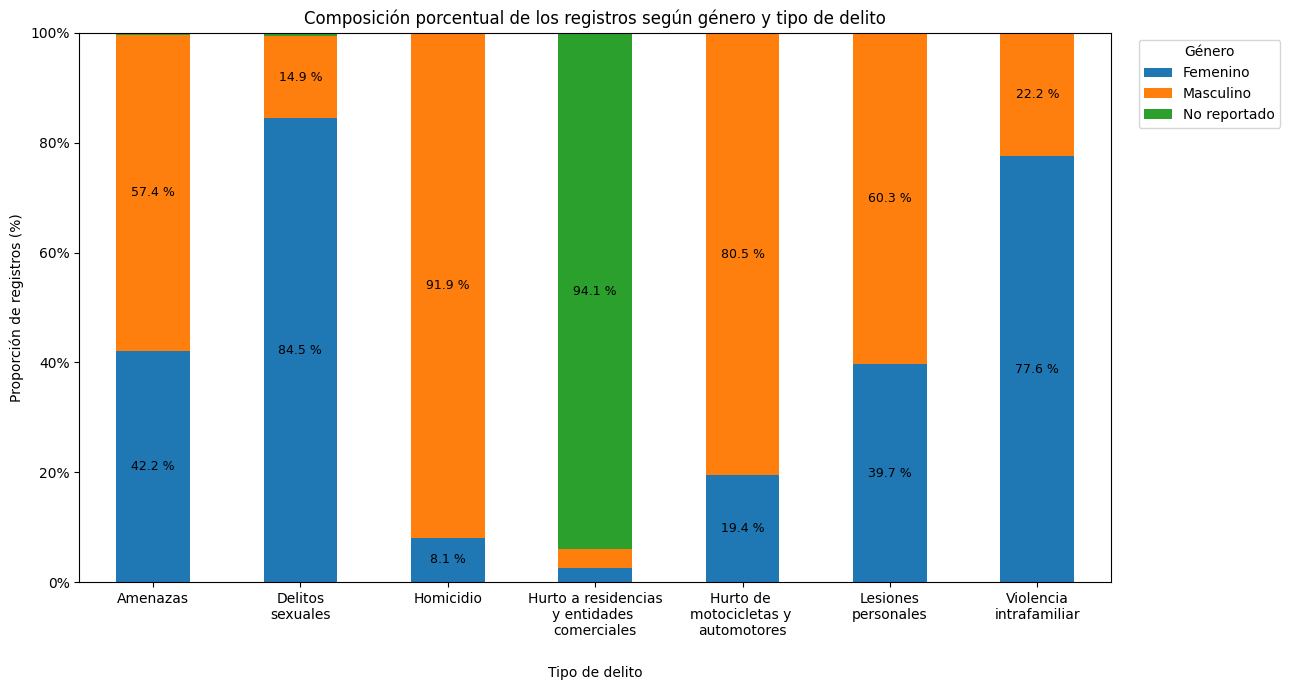

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ==========================================================
# PREPARACIÓN DE DATOS: TIPO DE DELITO × GÉNERO
# ==========================================================

# Convertir a tabla tipo_delito x genero
tabla_genero = df_genero.pivot_table(
    index="tipo_delito",
    columns="genero",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

# Calcular porcentaje dentro de cada tipo de delito
tabla_genero_pct = tabla_genero.div(
    tabla_genero.sum(axis=1),
    axis=0
) * 100

# Ordenar los delitos según el orden deseado
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

tabla_genero_pct = tabla_genero_pct.reindex(orden_delitos)

# ==========================================================
# GRÁFICA
# ==========================================================

ax = tabla_genero_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

ax.set_xlabel("Tipo de delito", labelpad=20)
ax.set_ylabel("Proporción de registros (%)")
ax.set_title(
    "Composición porcentual de los registros según género y tipo de delito, 2014–2024"
)

# Eje Y de 0 a 100
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())

# Rotación de etiquetas
ax.set_xticklabels(
    [
        "Amenazas",
        "Delitos\nsexuales",
        "Homicidio",
        "Hurto a residencias\ny entidades \ncomerciales",
        "Hurto de \nmotocicletas y \nautomotores",
        "Lesiones\npersonales",
        "Violencia\nintrafamiliar"
    ],
    rotation=0,
    ha="center"
)

for i in range(tabla_genero_pct.shape[0]):
    acumulado = 0
    
    for j in range(tabla_genero_pct.shape[1]):
        valor = tabla_genero_pct.iloc[i, j]
        
        if valor >= 5:
            ax.text(
                i,
                acumulado + valor / 2,
                f"{valor:.1f} %",
                ha="center",
                va="center",
                fontsize=9
            )
        
        acumulado += valor
        
ax.legend(
    title="Género",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [49]:
query_edad = """
SELECT
    d.tipo_delito,
    v.grupo_etario,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
GROUP BY
    d.tipo_delito,
    v.grupo_etario
ORDER BY
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_grupo = pd.read_sql(query_edad, engine)

print("Resultados: tipo de delito × grupo etario")
display(df_grupo)

Resultados: tipo de delito × grupo etario


,tipo_delito,grupo_etario,cantidad_delitos
0,Amenazas,Adultos,520701
1,Amenazas,Adolescentes,11265
2,Amenazas,Menores,4755
3,Amenazas,No reportado,213
4,Delitos sexuales,Adultos,199598
5,Delitos sexuales,Menores,61691
6,Delitos sexuales,Adolescentes,53270
7,Delitos sexuales,No reportado,324
8,Homicidio,Adultos,133285
9,Homicidio,Adolescentes,6495


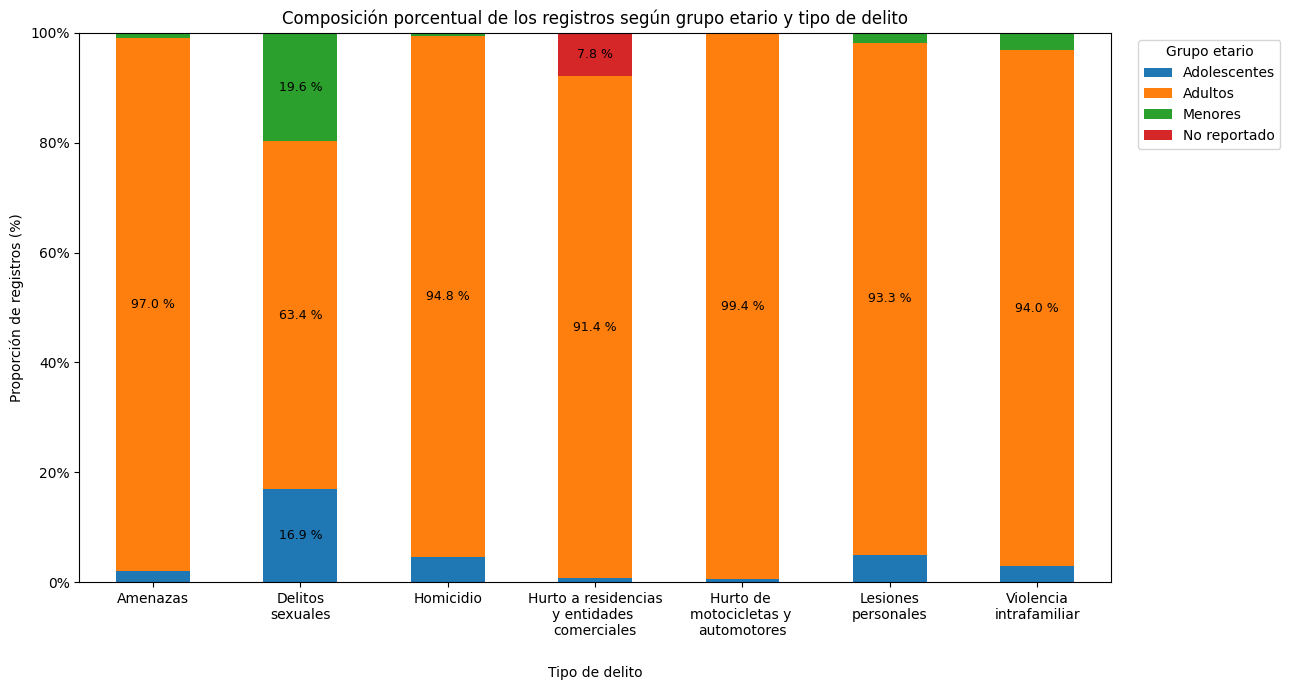

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ==========================================================
# PREPARACIÓN DE DATOS: TIPO DE DELITO × GRUPO ETARIO
# ==========================================================

tabla_edad = df_grupo.pivot_table(
    index="tipo_delito",
    columns="grupo_etario",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

# Calcular proporción dentro de cada tipo de delito
tabla_edad_pct = tabla_edad.div(
    tabla_edad.sum(axis=1),
    axis=0
) * 100

# Orden de los delitos
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

tabla_edad_pct = tabla_edad_pct.reindex(orden_delitos)

# ==========================================================
# GRÁFICA
# ==========================================================

ax = tabla_edad_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

ax.set_xlabel("Tipo de delito", labelpad=20)
ax.set_ylabel("Proporción de registros (%)")

ax.set_title(
    "Composición porcentual de los registros según grupo etario y tipo de delito"
)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())

# Etiquetas en dos líneas
ax.set_xticklabels(
    [
        "Amenazas",
        "Delitos\nsexuales",
        "Homicidio",
        "Hurto a residencias\ny entidades \ncomerciales",
        "Hurto de \nmotocicletas y \nautomotores",
        "Lesiones\npersonales",
        "Violencia\nintrafamiliar"
    ],
    rotation=0,
    ha="center"
)

# ==========================================================
# ETIQUETAS DE PORCENTAJE
# Solo mostrar segmentos >= 5 %
# ==========================================================

for i in range(tabla_edad_pct.shape[0]):
    acumulado = 0

    for j in range(tabla_edad_pct.shape[1]):
        valor = tabla_edad_pct.iloc[i, j]

        if valor >= 5:
            ax.text(
                i,
                acumulado + valor / 2,
                f"{valor:.1f} %",
                ha="center",
                va="center",
                fontsize=9
            )

        acumulado += valor

# ==========================================================
# LEYENDA
# ==========================================================

ax.legend(
    title="Grupo etario",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

##### **2.2. Caracterizacion de victimas en los municipios con mayor volumen de registros**

In [ ]:
query_municipio_genero = """
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
)

SELECT
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    v.genero,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
INNER JOIN top_municipios AS tm
    ON f.id_ubicacion = tm.id_ubicacion
GROUP BY
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    v.genero,
    tm.total_municipio
ORDER BY
    tm.total_municipio DESC,
    tm.municipio,
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_municipio_genero = pd.read_sql(
    query_municipio_genero,
    engine
)

print("Resultados del análisis municipio × tipo de delito × género:")
display(df_municipio_genero)

ProgrammingError: (psycopg2.errors.GroupingError) la columna «tm.total_municipio» debe aparecer en la cláusula GROUP BY o ser usada en una función de agregación
LINE 38:     tm.total_municipio DESC,
             ^

[SQL: 
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
)

SELECT
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    v.genero,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
INNER JOIN top_municipios AS tm
    ON f.id_ubicacion = tm.id_ubicacion
GROUP BY
    tm.municipio,
    tm.departam

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

# ==========================================================
# PREPARACIÓN DE LOS DATOS
# ==========================================================

# Normalizar género
df_municipio_genero["genero_limpio"] = (
    df_municipio_genero["genero"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Orden de los tipos de delito
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

# ----------------------------------------------------------
# Total de registros por municipio y tipo de delito
# Incluye FEMENINO, MASCULINO y NO REPORTA
# ----------------------------------------------------------

totales_municipio_delito = (
    df_municipio_genero
    .groupby(
        ["municipio", "departamento", "tipo_delito"],
        as_index=False
    )["cantidad_delitos"]
    .sum()
    .rename(columns={"cantidad_delitos": "total_delito"})
)

# ----------------------------------------------------------
# Orden de municipios según su volumen total
# ----------------------------------------------------------

orden_municipios = (
    df_municipio_genero
    .groupby(["municipio", "departamento"])["cantidad_delitos"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# ==========================================================
# FUNCIÓN PARA GENERAR EL HEATMAP
# ==========================================================

def crear_heatmap_genero_porcentaje(df, genero, titulo):

    # ------------------------------------------------------
    # Filtrar el género
    # ------------------------------------------------------

    df_genero = df[
        df["genero_limpio"] == genero
    ].copy()

    if df_genero.empty:
        print(f"No se encontraron registros para {genero}.")
        return

    # ------------------------------------------------------
    # Unir el total municipio × delito
    # ------------------------------------------------------

    df_genero = df_genero.merge(
        totales_municipio_delito,
        on=["municipio", "departamento", "tipo_delito"],
        how="left"
    )

    # ------------------------------------------------------
    # Calcular porcentaje
    # ------------------------------------------------------

    df_genero["porcentaje"] = (
        df_genero["cantidad_delitos"]
        / df_genero["total_delito"]
    ) * 100

    # ------------------------------------------------------
    # Matriz de cantidades
    # ------------------------------------------------------

    tabla_cantidad = df_genero.pivot_table(
        index=["municipio", "departamento"],
        columns="tipo_delito",
        values="cantidad_delitos",
        aggfunc="sum",
        fill_value=0
    )

    # ------------------------------------------------------
    # Matriz de porcentajes
    # ------------------------------------------------------

    tabla_porcentaje = df_genero.pivot_table(
        index=["municipio", "departamento"],
        columns="tipo_delito",
        values="porcentaje",
        aggfunc="sum",
        fill_value=0
    )

    # Asegurar orden de columnas
    tabla_cantidad = tabla_cantidad.reindex(
        columns=orden_delitos,
        fill_value=0
    )

    tabla_porcentaje = tabla_porcentaje.reindex(
        columns=orden_delitos,
        fill_value=0
    )

    # Asegurar orden de municipios
    tabla_cantidad = tabla_cantidad.reindex(
        orden_municipios,
        fill_value=0
    )

    tabla_porcentaje = tabla_porcentaje.reindex(
        orden_municipios,
        fill_value=0
    )

    datos = tabla_cantidad.to_numpy()
    porcentajes = tabla_porcentaje.to_numpy()

    # ------------------------------------------------------
    # Escala logarítmica para el color
    # ------------------------------------------------------

    valores_positivos = datos[datos > 0]

    if valores_positivos.size == 0:
        print(f"No hay valores positivos para {genero}.")
        return

    norm = LogNorm(
        vmin=valores_positivos.min(),
        vmax=valores_positivos.max()
    )

    # ======================================================
    # FIGURA
    # ======================================================

    fig, ax = plt.subplots(figsize=(15, 8))

    imagen = ax.imshow(
        datos,
        aspect="auto",
        norm=norm
    )

    # ------------------------------------------------------
    # Eje X
    # ------------------------------------------------------

    etiquetas_delitos = [
        "Amenazas",
        "Delitos\nsexuales",
        "Homicidio",
        "Hurto a residencias\ny entidades \ncomerciales",
        "Hurto de \nmotocicletas y \nautomotores",
        "Lesiones\npersonales",
        "Violencia\nintrafamiliar"
    ]

    ax.set_xticks(np.arange(len(orden_delitos)))
    ax.set_xticklabels(
        etiquetas_delitos,
        rotation=0,
        ha="center"
    )

    ax.set_xlabel(
        "Tipo de delito",
        labelpad=20
    )

    # ------------------------------------------------------
    # Eje Y
    # ------------------------------------------------------

    etiquetas_municipios = [
        f"{municipio} — {departamento}"
        for municipio, departamento in orden_municipios
    ]

    ax.set_yticks(np.arange(len(etiquetas_municipios)))
    ax.set_yticklabels(etiquetas_municipios)

    ax.set_ylabel("Municipio")

    ax.set_title(titulo)

    # ------------------------------------------------------
    # Etiquetas: cantidad + porcentaje
    # ------------------------------------------------------

    for i in range(datos.shape[0]):
        for j in range(datos.shape[1]):

            cantidad = datos[i, j]
            porcentaje = porcentajes[i, j]

            if cantidad > 0:

                texto_cantidad = (
                    f"{int(cantidad):,}".replace(",", ".")
                )

                texto = (
                    f"{texto_cantidad}\n"
                    f"({porcentaje:.1f} %)"
                )
                # Obtener el color de fondo de la celda
                rgba = imagen.cmap(norm(cantidad))

                # Calcular luminancia del color
                r, g, b, _ = rgba

                luminancia = (
                    0.299 * r +
                    0.587 * g +
                    0.114 * b
                )

                # Fondo oscuro -> texto blanco
                # Fondo claro -> texto negro
                color_texto = "white" if luminancia < 0.5 else "black"

                ax.text(
                    j,
                    i,
                    texto,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=color_texto,
                    linespacing=1.1
                )

    # ------------------------------------------------------
    # Barra de color
    # ------------------------------------------------------

    cbar = fig.colorbar(
        imagen,
        ax=ax
    )

    cbar.set_label(
        "Cantidad de registros"
    )

    cbar.ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos:
            f"{int(x):,}".replace(",", ".")
        )
    )

    plt.tight_layout()
    plt.show()

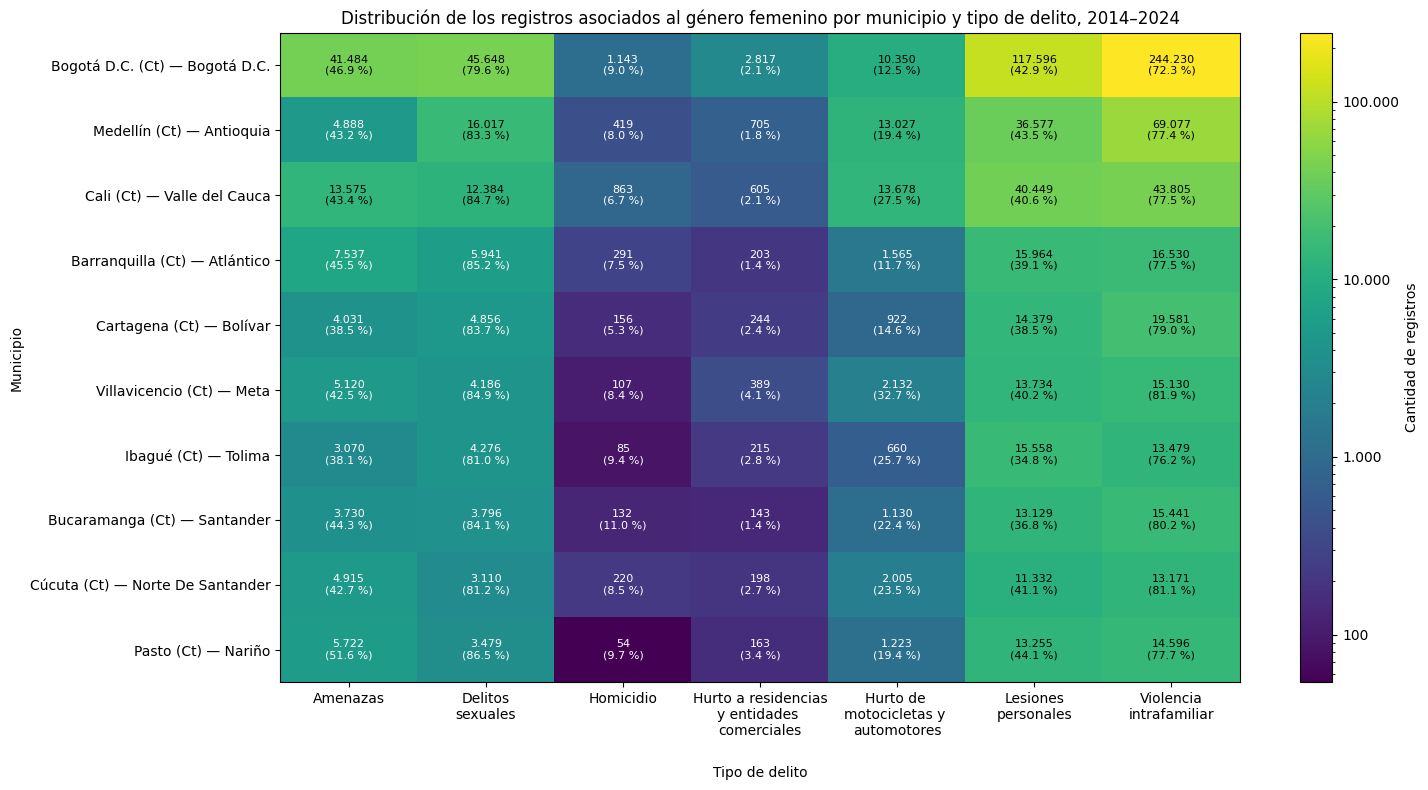

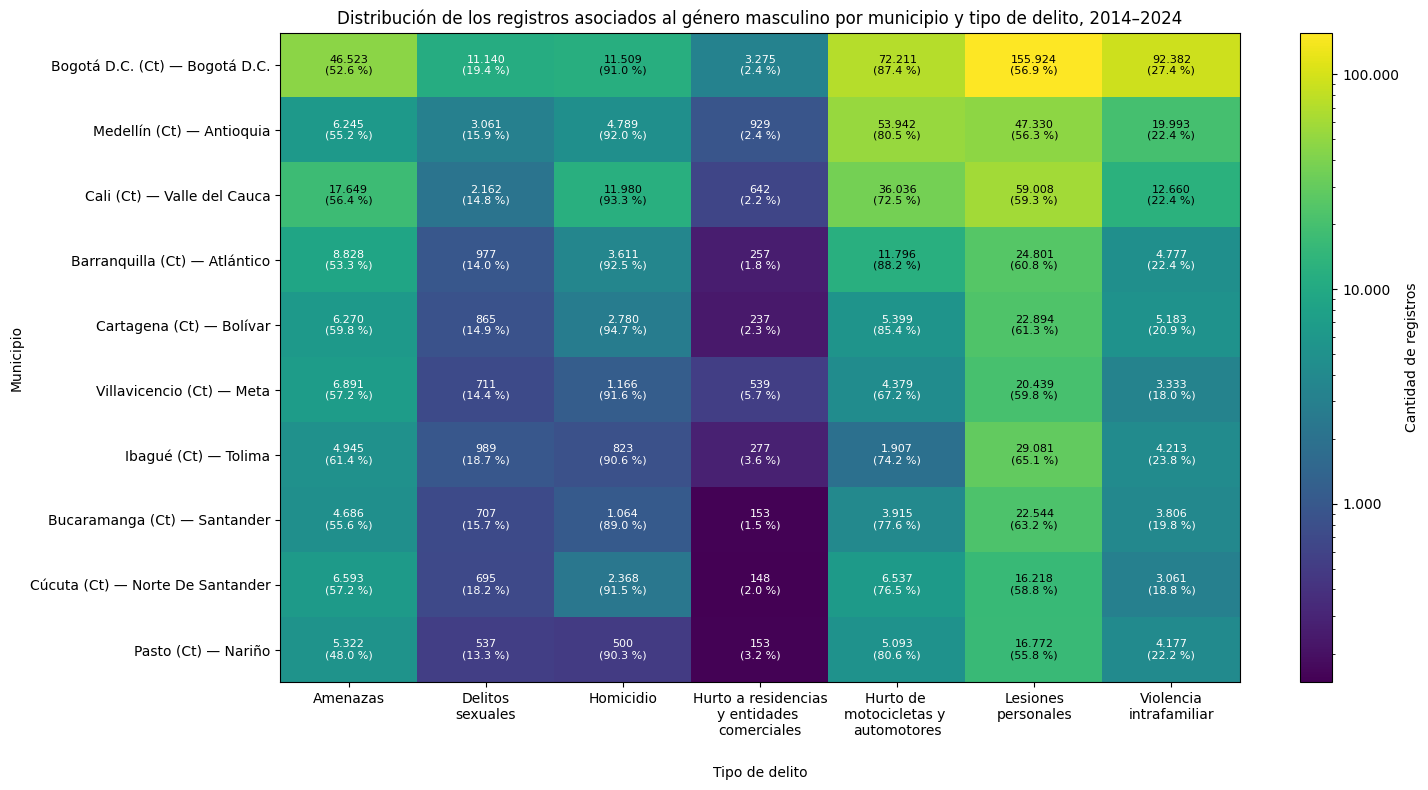

In [44]:
crear_heatmap_genero_porcentaje(
    df_municipio_genero,
    "FEMENINO",
    "Distribución de los registros asociados al género femenino por municipio y tipo de delito, 2014–2024"
)

crear_heatmap_genero_porcentaje(
    df_municipio_genero,
    "MASCULINO",
    "Distribución de los registros asociados al género masculino por municipio y tipo de delito, 2014–2024"
)